# Unit 5｜SMA / WMA / EMA 均線計算與視覺化

**課程：Python 數據分析套件實作**  

---

## 學習目標

1. 理解三種均線（SMA / WMA / EMA）的計算原理與差異
2. 從零手刻 `smacal()`、`wmacal()`、`emaCal()` 函數
3. 使用 TA-Lib 快速計算並與手刻版本對照驗證
4. 以 matplotlib 繪製均線圖
5. 實作**突破均線策略**與**均線排列策略**並評估績效


In [42]:
import pandas as pd
import numpy as np

# 讀取檔案
stock = pd.read_csv('2327.csv', encoding='big5')
stock.head(20)
stock.tail(20)

# 欄位的更名
stock = stock.rename(columns={'證券代碼':'coid', '簡稱':'name', '年月日':'date',
            '開盤價(元)':'open', '最高價(元)':'high', '最低價(元)':'low',
            '收盤價(元)':'close', '成交量(千股)':'volume'})
stock

# 欄位的刪除
stock = stock.drop(columns=['coid', 'name'])
stock

# 時間格式的變更
stock['date'] = pd.to_datetime(stock['date'], format='%Y%m%d')
stock

# 將日期設為索引
stock = stock.set_index('date')
stock.head()

stock.to_csv('2327_Final.csv', encoding='utf8')
stock

,open,high,low,close,volume
date,,,,,
2000-01-04,38.3,38.8,37.5,37.5,75810
2000-01-05,35.2,37.5,35.2,36.2,55597
2000-01-06,36.2,37.4,35.8,36.4,61787
2000-01-07,36.4,37.4,36.4,36.6,57708
2000-01-10,37.2,38.5,36.8,37.8,61759
...,...,...,...,...,...
2026-06-22,1115.0,1120.0,1040.0,1065.0,62351
2026-06-23,1060.0,1085.0,1020.0,1020.0,46353
2026-06-24,1005.0,1075.0,985.0,1050.0,49108


In [43]:
# 讀取資料

stock = pd.read_csv('2327_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
# stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc[:] # 這個是利用loc方法進行資料選取
stock

,open,high,low,close,volume
date,,,,,
2000-01-04,38.3,38.8,37.5,37.5,75810
2000-01-05,35.2,37.5,35.2,36.2,55597
2000-01-06,36.2,37.4,35.8,36.4,61787
2000-01-07,36.4,37.4,36.4,36.6,57708
2000-01-10,37.2,38.5,36.8,37.8,61759
...,...,...,...,...,...
2026-06-22,1115.0,1120.0,1040.0,1065.0,62351
2026-06-23,1060.0,1085.0,1020.0,1020.0,46353
2026-06-24,1005.0,1075.0,985.0,1050.0,49108


## 1. 簡單移動平均數（SMA — Simple Moving Average）

SMA 是最基本的均線，每一天的值等於**過去 k 日收盤價的算術平均**：

$$SMA_t = \\frac{Close_{t} + Close_{t-1} + \\cdots + Close_{t-k+1}}{k}$$

所有天的權重相同，優點是計算簡單，缺點是對近期價格反應較慢。


In [44]:
# 使用Python來計算5日簡單移動平均數

# 建立一個跟stock有相同索引的Series,目的是為了可以讓stock進行合併或比對
sma5 = pd.Series(np.nan, index=stock['close'].index)

# 用for迴圈逐日計算5日簡單移動平均數
# 因為range(4.....)，從第5筆(索引4)開始，一直到
for i in range(4, len(stock['close'])):
  # 取從第i-4筆到第i筆，總共有5筆收盤價
  # 假如:i=4時，取iloc[0:5]，也就是第1-5筆
  # 假如:i=5時，取iloc[1:6]，也就是第2-6筆
  # 假如:i=6時，取iloc[2:7]，也就是第3-7筆
  # 將計算結果存入到sma5的第i個位置
  sma5.iloc[i] = np.mean(stock['close'].iloc[(i-4):(i+1)])

sma5.head(10)

,0
date,
2000-01-04,NaN
2000-01-05,NaN
2000-01-06,NaN
2000-01-07,NaN
2000-01-10,36.90
2000-01-11,37.06
2000-01-12,37.90
2000-01-13,39.24
2000-01-14,39.98


| 索引 | 日期       | 收盤價 | 計算範圍（iloc）    | SMA10              |
|------|------------|--------|---------------------|---------------------|
| 0    | 2014-01-02 | 100    | 資料不足，維持 0.0   | 0.0                 |
| 1    | 2014-01-03 | 102    | 資料不足，維持 0.0   | 0.0                 |
| ...  | ...        | ...    | ...                  | ...                 |
| 8    | 2014-01-13 | 108    | 資料不足，維持 0.0   | 0.0                 |
| 9    | 2014-01-14 | 110    | iloc[0:10]（10筆）  | mean(100~110)       |
| 10   | 2014-01-15 | 107    | iloc[1:11]（10筆）  | mean(102~107)       |
| 11   | 2014-01-16 | 112    | iloc[2:12]（10筆）  | mean(...)           |

In [45]:
# 簡單移動平均數的函數化

def smacal(price, k):
  sma = pd.Series([np.nan]*len(price), index=price.index)

  for i in range(k-1, len(price)):
    sma.iloc[i] = np.mean(price.iloc[(i-k+1):(i+1)])
  return sma

smacal(stock['close'], 5).head(10)

,0
date,
2000-01-04,NaN
2000-01-05,NaN
2000-01-06,NaN
2000-01-07,NaN
2000-01-10,36.90
2000-01-11,37.06
2000-01-12,37.90
2000-01-13,39.24
2000-01-14,39.98


## 2. 加權移動平均數（WMA — Weighted Moving Average）

WMA 對**近期價格給予較高的權重**，越近的交易日權重越大：

$$WMA_t = \\frac{k \\cdot Close_t + (k-1) \\cdot Close_{t-1} + \\cdots + 1 \\cdot Close_{t-k+1}}{k + (k-1) + \\cdots + 1}$$

相較於 SMA，WMA 對近期價格變動的反應更靈敏。


In [46]:
# 計算5日加權移動平均數

# 定義每一天的權重值
b = np.array([5, 4, 3, 2, 1])
w = b / sum(b)
w

wma5 = pd.Series([np.nan]*len(stock['close']), index=stock['close'].index)

for i in range(4, len(stock['close'])):
  wma5.iloc[i] = np.sum(w * stock['close'].iloc[(i-4):(i+1)])

wma5.head(10).round(2)

,0
date,
2000-01-04,NaN
2000-01-05,NaN
2000-01-06,NaN
2000-01-07,NaN
2000-01-10,36.83
2000-01-11,36.69
2000-01-12,37.25
2000-01-13,38.20
2000-01-14,39.33


In [47]:
# 加權移動平均數的函數化

def wmacal(price, weight):
  # 定義權重
  k = len(weight)
  arrweight = np.array(weight)
  arrweight_1 = arrweight / sum(arrweight)
  wma = pd.Series([np.nan]*len(price), index=price.index)

  for i in range(k-1, len(price.index)):
    wma.iloc[i] = sum(arrweight_1 * price.iloc[(i-k+1):(i+1)])
  return wma

wmacal(stock['close'], [5, 4, 3, 2, 1]).round(2).head(10)

,0
date,
2000-01-04,NaN
2000-01-05,NaN
2000-01-06,NaN
2000-01-07,NaN
2000-01-10,36.83
2000-01-11,36.69
2000-01-12,37.25
2000-01-13,38.20
2000-01-14,39.33


## 3. 指數加權移動平均（EMA — Exponential Moving Average）

EMA 使用**遞推公式**，每一天的值都考慮到所有歷史資料，近期價格的影響呈指數衰減：

$$EMA_t = \\alpha \\cdot Close_t + (1-\\alpha) \\cdot EMA_{t-1}$$

其中平滑係數 $\\alpha = \\dfrac{2}{k+1}$（k 為週期），初始值取前 k 日的 SMA。

> 💡 EMA 是技術分析中最常用的均線，MACD 指標也是以 EMA 為基礎計算。


In [54]:
# 指數加權移動平均數的計算

ema5 = pd.Series([np.nan]*len(stock['close']), index=stock['close'].index)
ema5.iloc[4] = np.mean(stock['close'].iloc[:5])

for i in range(5, len(stock['close'])):
  ema5.iloc[i] = (0.2 * stock['close'].iloc[i]) + ((1-0.2) * ema5.iloc[i-1])

ema5.head(10).round(2)

,0
date,
2000-01-04,NaN
2000-01-05,NaN
2000-01-06,NaN
2000-01-07,NaN
2000-01-10,36.90
2000-01-11,37.18
2000-01-12,37.82
2000-01-13,38.88
2000-01-14,39.16


In [56]:
# 指數加權移動平均數的函數化

def emacal(price, period, exponential):
  ema = pd.Series([np.nan]*len(price), index=price.index)
  ema.iloc[period-1] = np.mean(price.iloc[:period])

  for i in range(period, len(price)):
    ema.iloc[i] = (exponential*price.iloc[i])+((1-exponential)*ema.iloc[i-1])
  return ema

emacal(stock['close'], 5, 0.2).head(20).round(2)

,0
date,
2000-01-04,NaN
2000-01-05,NaN
2000-01-06,NaN
2000-01-07,NaN
2000-01-10,36.90
2000-01-11,37.18
2000-01-12,37.82
2000-01-13,38.88
2000-01-14,39.16


## 4. 使用 TA-Lib 快速計算均線

TA-Lib（Technical Analysis Library）是金融技術指標的標準套件，
內建超過 150 種指標，計算速度遠快於手刻版本。

常用均線函數：

| 函數 | 說明 |
|---|---|
| `talib.SMA(price, k)` | 簡單移動平均 |
| `talib.WMA(price, k)` | 加權移動平均 |
| `talib.EMA(price, k)` | 指數移動平均 |
| `talib.DEMA(price, k)` | 雙重指數移動平均 |
| `talib.TEMA(price, k)` | 三重指數移動平均 |
| `talib.TRIMA(price, k)` | 三角移動平均 |
| `talib.KAMA(price, k)` | 考夫曼自適應移動平均 |

> ⚠️ 第一次使用前需安裝：`!pip install ta-lib`


In [70]:
# !pip install ta-lib

import talib

stock['SMA5'] = talib.SMA(stock['close'], 5) # 簡單移動平均數
stock.head(10)
stock['WMA5'] = talib.WMA(stock['close'], 5) # 加權移動平均數
stock.head(10)
stock['EMA5'] = talib.EMA(stock['close'], 5) # 指數加權移動平均數
stock.head(10)
stock['DEMA5'] = talib.DEMA(stock['close'], 5) # 雙指數加權移動平均數
stock.head(10)
stock['TEMA5'] = talib.TEMA(stock['close'], 5) # 三次指數加權移動平均數
stock.head(20)
stock['TRIMA5'] = talib.TRIMA(stock['close'], 5) # 三角移動平均數
stock.head(20)
stock['KAMA5'] = talib.KAMA(stock['close'], 5) # 考夫曼自適應移動平均數
stock.head(20)

,open,high,low,close,volume,SMA5,WMA5,EMA5,DEMA5,TEMA5,TRIMA5,KAMA5
date,,,,,,,,,,,,
2000-01-04,38.3,38.8,37.5,37.5,75810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,35.2,37.5,35.2,36.2,55597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,36.2,37.4,35.8,36.4,61787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,36.4,37.4,36.4,36.6,57708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-10,37.2,38.5,36.8,37.8,61759,36.90,36.966667,36.900000,NaN,NaN,36.677778,NaN
2000-01-11,38.5,39.2,37.8,38.3,96470,37.06,37.433333,37.366667,NaN,NaN,36.966667,37.821259
2000-01-12,39.2,40.9,39.2,40.4,130877,37.90,38.546667,38.377778,NaN,NaN,37.777778,38.967366
2000-01-13,42.4,43.2,41.3,43.1,139755,39.24,40.280000,39.951852,NaN,NaN,39.000000,40.804092
2000-01-14,43.3,43.3,40.1,40.3,86751,39.98,40.633333,40.067901,41.602963,NaN,40.233333,40.757481


## 5. 策略實作 1：突破均線交易策略

利用 EMA 作為動態支撐壓力，設計進出場條件：

- **進場條件**：當收盤價 > EMA5 × 1.01（突破均線上方 1%）
- **出場條件**：當收盤價 < EMA5 × 0.995（跌破均線下方 0.5%）

加入緩衝百分比的設計是為了避免均線附近的頻繁假突破。


In [74]:
# 計算交易績效指標的計算
import matplotlib.pyplot as plt

def Performance(trade=pd.DataFrame(), prodtype='Stock'):
  # 防呆機制:若沒有交易紀錄，直接結束函數
  if trade.shape[0] == 0:
    print('沒有交易紀錄')
    return False

  # 將trade物件複製，避免影響原始trade的內容
  trade1 = trade.copy()
  trade1 = trade.sort_values(4)
  trade1 = trade.reset_index(drop=True)

  # 定義交易明細表的欄位
  trade1.columns = ['product', 'bs', 'order_time', 'order_price', 'cover_time',
            'cover_price', 'order_unit']

  # 判斷交易成本的計算
  if prodtype == 'ETF':
    comm_rate = 0.001425 # 交易手續費約0.1425%
    tax_rare = 0.001 # 證交稅約0.1%(只有賣出股票的時候才會扣)
  elif prodtype == 'Stock':
    comm_rate = 0.001425 # 交易手續費約0.1425%
    tax_rare = 0.003 # 證交稅約0.3%(只有賣出股票的時候才會扣)
  else:
    return False

  # 計算每筆交易的成本與損益
  # 計算買進股票的手續費
  fee_buy = trade1['order_price'] * trade1['order_unit'] * comm_rate

  # 計算賣出股票的手續費
  fee_sell = trade1['cover_price'] * trade1['order_unit'] * comm_rate

  # 計算賣出股票的稅金
  tax = trade1['cover_price'] * trade1['order_unit'] * tax_rare

  # 買入成本 = 買入價格+買入手續費
  cost_basis = trade1['order_price'] * trade1['order_unit'] + fee_buy

  # 賣出的淨利潤
  net_profit = (trade1['cover_price'] * trade1['order_unit']) - \
          (trade1['order_price'] * trade1['order_unit']) - fee_buy - \
          fee_sell - tax

  # 計算報酬率:每筆報酬率 = 淨利潤 / 買進成本
  trade1['ret'] = net_profit / cost_basis

  # 總報酬率:代表交易紀錄的報酬率之累加
  print(f'總報酬率:{trade1['ret'].sum():.3f}')

  # 總交易次數
  print(f'交易次數:{trade1.shape[0]}')

  # 平均報酬率:每筆交易的平均獲利/虧損
  print(f'平均報酬率:{trade1['ret'].mean():.3f}')

  # 判斷是否獲利或虧損:將交易紀錄拆分為獲利與虧損
  earn_trade = trade1[trade1['ret'] > 0] # 報酬率>0:獲利的交易
  loss_trade = trade1[trade1['ret'] <= 0] # 報酬率<=0:虧損或打平的交易

  # 防呆機制:若全勝或全敗(無法計算賺賠比),直接結束
  if earn_trade.shape[0] == 0 or loss_trade.shape[0] == 0:
    print('交易資料樣本不足(樣本中要有賺有賠)')
    return False

  # 計算勝率:獲利筆數 / 交易次數
  earn_ratio = earn_trade.shape[0] / trade1.shape[0]
  print(f'勝率%:{earn_ratio:.3f}')

  # 平均獲利:獲利交易的平均報酬率
  avg_earn = earn_trade['ret'].mean()
  print(f'平均獲利:{avg_earn:.3f}')

  # 平均虧損:虧損交易的平均報酬率(負值)
  avg_loss = loss_trade['ret'].mean()
  print(f'平均虧損:{avg_loss:.3f}')

  # 賺賠比:平均獲利 / 平均虧損,然後取絕對值
  # 代表[平均每賺1元，最多虧多少錢], 賺賠比要越大越好(建議 > 1.5)
  odds = abs(avg_earn / avg_loss)
  print(f'賺賠比:{odds:.3f}')

  # 最大連續虧損
  # 邏輯:遇到虧損就進行累乘,遇到獲利就重置為1
  # 目的:衡量連續虧損時,資金最大萎縮的幅度
  tmp_accloss = 1 # 暫存當前的連續虧損的累乘值
  max_accloss = 1 # 紀錄歷史最大的連續虧損值

  for ret in trade1['ret'].values:
    if ret <= 0:
      tmp_accloss = tmp_accloss * ret # 連續虧損:持續進行累乘
      max_accloss = min(max_accloss, tmp_accloss) # 取最小值(最大虧損)
    else:
      tmp_accloss = 1 # 遇到獲利的狀態,重置為1,以便重新計算
  print(f'最大連續虧損:{max_accloss:.3f}')

  # 計算累積報酬率:目的是為了畫出資金曲線圖
  # cumprod():累積乘積,模擬每筆交易後資金的複利狀態
  trade1['acc_ret'] = (1+trade1['ret']).cumprod()

  # 計算最大資金回落
  # 步驟1:計算截至目前為止的歷史最高的累積報酬率
  trade1['acc_max_cap'] = trade1['acc_ret'].cummax()

  # 步驟2:當前的累積報酬率 / 歷史最高的累積報酬率 = 目前從最高點回落的比例
  trade1['dd'] = trade1['acc_ret'] / trade1['acc_max_cap']

  # 步驟3:標記每次創新高的點(在圖上顯示紅點)
  # 當trade1['acc_ret'] == trade1['acc_max_cap']時,代表該筆交易後資金創歷史新高
  trade1.loc[trade1['acc_ret'] == trade1['acc_max_cap'], 'new_high'] = trade1['acc_ret']

  # MDD = 1 - dd的最小值(也就是回落最深的那個點距離最高點的幅度)
  print(f'最大資金回落;{(1-trade1['dd'].min()):.3f}')

  # 繪製資金曲線圖
  ax = plt.subplot(111) # 建立子圖

  # 藍線(Profit):累積報酬率曲線，代表資金成長的走勢
  ax.plot(trade1['acc_ret'], 'b-', label='Profit')

  # 綠線(MDD):每筆交易相對歷史高點的回落比例
  ax.plot(trade1['dd'], '-', color='g', label='MDD')

  # 紅點:每次累積報酬率創歷史新高的交易點
  ax.plot(trade1['new_high'], 'o', color='r', label='Equity high')

  plt.legend() # 顯示圖例
  plt.show() # 顯示圖形


總報酬率:1.922
交易次數:450
平均報酬率:0.004
勝率%:0.320
平均獲利:0.101
平均虧損:-0.041
賺賠比:2.447
最大連續虧損:-0.734
最大資金回落;0.947


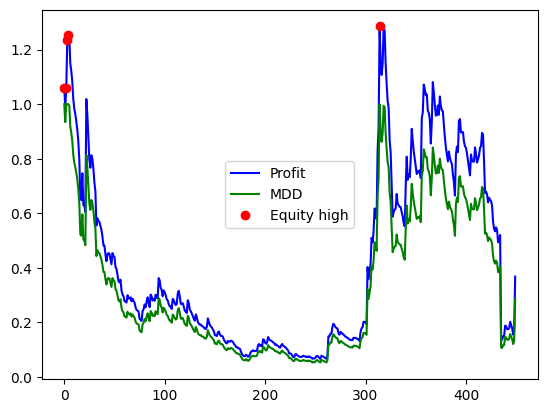

In [77]:
# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價
  c_ema = stock.loc[c_time, 'EMA5']

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_close > c_ema * 1.01: # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_close < c_ema * 0.995: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
# trade
# ChartTrade(stock[:], trade[:])
Performance(trade, 'Stock')

#### 🖊️ 隨堂練習 5-1

**均線排列交易策略**

利用三條不同週期的 EMA 排列關係判斷趨勢強度：

- **進場條件**：EMA7 > EMA14 > EMA30（多頭排列）
- **出場條件**：上述排列條件不成立

三線多頭排列代表短、中、長期趨勢一致向上，是趨勢跟隨策略的常見訊號。


總報酬率:3.936
交易次數:137
平均報酬率:0.029
勝率%:0.372
平均獲利:0.176
平均虧損:-0.059
賺賠比:2.998
最大連續虧損:-0.212
最大資金回落;0.865


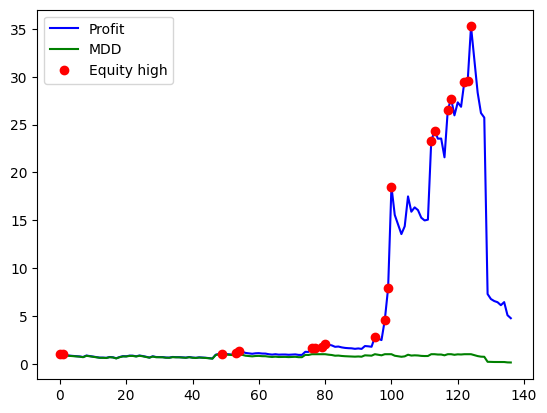

In [80]:
stock['EMA7'] = talib.EMA(stock['close'], 7)
stock['EMA14'] = talib.EMA(stock['close'], 14)
stock['EMA30'] = talib.EMA(stock['close'], 30)
stock

# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價
  c_ema7 = stock.loc[c_time, 'EMA7']
  c_ema14 = stock.loc[c_time, 'EMA14']
  c_ema30 = stock.loc[c_time, 'EMA30']

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_ema7 > c_ema14 > c_ema30: # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if not c_ema7 > c_ema14 > c_ema30: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
# trade
# ChartTrade(stock[:], trade[:])
Performance(trade, 'Stock')

# Unit 6｜RSI 相對強弱指標計算與交易策略

**課程：Python 數據分析套件實作（Day 1 下午）**  

---

## 學習目標

1. 理解 RSI 的計算原理（漲跌幅分離→滾動平均→RSI 公式）
2. 手刻 `rsi()` 函數並以 talib.RSI 驗證
3. 繪製 RSI 超買超賣圖（單圖 / 雙子圖）
4. 實作雙 RSI 突破策略與強勢回檔策略


In [ ]:
stock['RSI5'] = talib.RSI(stock['close'], 5)
stock

#### 🖊️ 隨堂練習 5-2
**雙 RSI 突破策略**

利用兩條不同週期 RSI 的相對關係判斷多空：

- **進場**：短週期 RSI（120日）> 長週期 RSI（150日）→ 短期動能優於長期，多頭訊號
- **出場**：短週期 RSI < 長週期 RSI → 動能反轉，出場

總報酬率:4.576
交易次數:110
平均報酬率:0.042
勝率%:0.264
平均獲利:0.284
平均虧損:-0.045
賺賠比:6.294
最大連續虧損:-0.247
最大資金回落;0.796


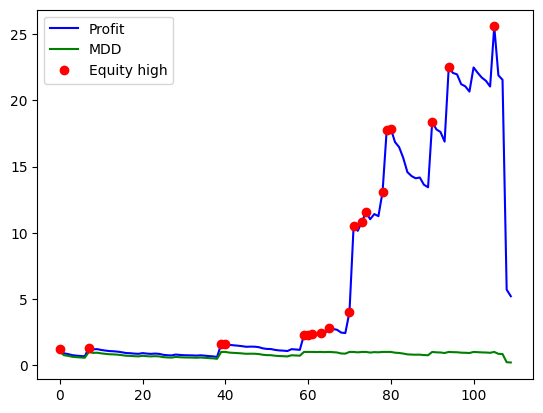

In [82]:
stock['RSI120'] = talib.RSI(stock['close'], 120)
stock['RSI150'] = talib.RSI(stock['close'], 150)

# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價
  c_rsi120 = stock.loc[c_time, 'RSI120']
  c_rsi150 = stock.loc[c_time, 'RSI150']

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_rsi120 > c_rsi150: # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_rsi120 < c_rsi150: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
# trade
# ChartTrade(stock[:], trade[:])
Performance(trade, 'Stock')

#### 🖊️ 隨堂練習 5-3

**強勢回檔策略**

在多頭趨勢中，等待 RSI 短暫回落至低點後反彈，以較好的價格進場：

- **進場**：RSI5 < 40（回檔至超賣邊緣），且在 3 日內從最低點反彈超過 10
- **出場**：RSI5 > 80（進入超買區，獲利了結）

> 💡 `rsi_min` 追蹤觀察期間的 RSI 最低值，確認「最低點已出現並開始反彈」才進場。


總報酬率:0.732
交易次數:62
平均報酬率:0.012
勝率%:0.677
平均獲利:0.108
平均虧損:-0.191
賺賠比:0.568
最大連續虧損:-0.568
最大資金回落;0.878


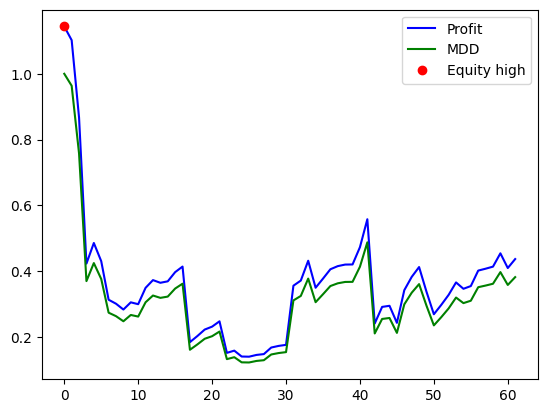

In [93]:
# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

# 計算RSI的買超和賣超
over_buy = 80
over_sell = 40

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態
# rsi_min代表交易時間內最小的RSI值, rsi_min_time記錄最小RSI值的時間
rsi_min, rsi_min_time = 100, 0

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價
  c_rsi = stock.loc[c_time, 'RSI5']

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_rsi < over_sell: # 當天的收盤價大於當天的開盤價
      if rsi_min > c_rsi:
        rsi_min = c_rsi
        rsi_min_time = i
        continue
      if i <= rsi_min_time + 3 and c_rsi > rsi_min + 10:
        rsi_min = 100
        rsi_min_time = 0
        position = 1 # 部位設成1，代表有股票在手上
        order_i = i # 訂單編號
        order_time = n_time # 隔天的開盤時間
        order_price = n_open # 隔天的開盤價
        order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_rsi > over_buy: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
# trade
# ChartTrade(stock[:], trade[:])
Performance(trade, 'Stock')